In [1]:
!pip install torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink


image 1/1 /content/51.jpg: 448x640 1 person, 1 bottle, 2 bowls, 1 apple, 1 orange, 371.4ms
Speed: 16.4ms preprocess, 371.4ms inference, 35.2ms postprocess per image at shape (1, 3, 448, 640)


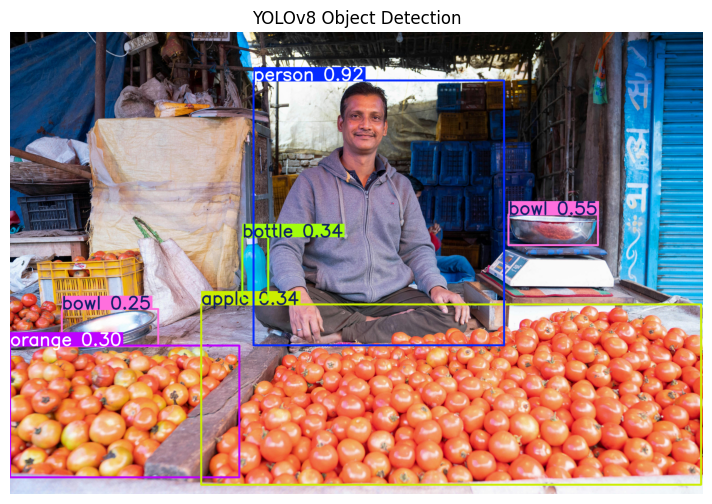

In [4]:
# YOLOv8 (Ultralytics) for Object Detection
!pip install ultralytics  # Install YOLOv8
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLOv8 model (pretrained on COCO)
model = YOLO("yolov8n.pt")  # Nano version (smallest)

# Perform object detection
# Replace with the correct absolute path to your image
image_path = "/content/51.jpg"
results = model(image_path)

# Show results
plt.figure(figsize=(10, 6))
plt.imshow(results[0].plot()[:, :, ::-1])  # BGR to RGB
plt.axis('off')
plt.title("YOLOv8 Object Detection")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


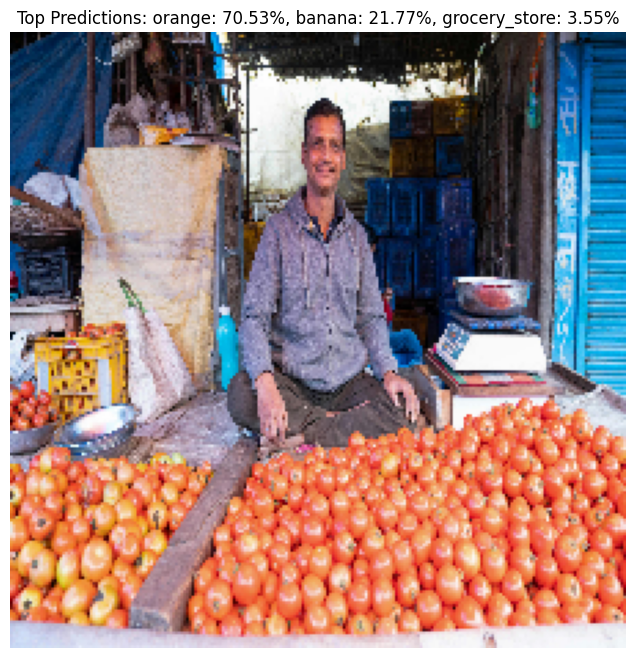

In [6]:
# CNN for Image Classification (using ResNet50)
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
import numpy as np
import matplotlib.pyplot as plt

# Load pretrained ResNet50
model = ResNet50(weights="imagenet")

# Load and preprocess image
img = tf.keras.utils.load_img("/content/51.jpg", target_size=(224, 224))  # Replace with your image
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict and decode results
predictions = model.predict(img_array)
decoded_preds = decode_predictions(predictions, top=3)[0]

# Display results
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f"Top Predictions: {', '.join([f'{x[1]}: {x[2]*100:.2f}%' for x in decoded_preds])}")
plt.show()

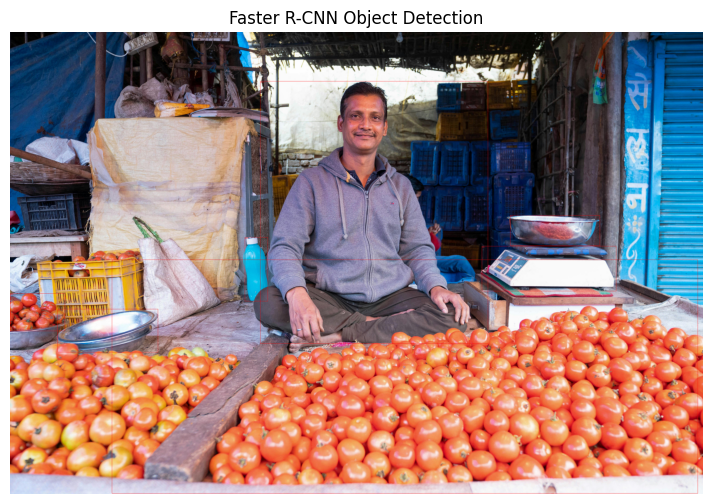

In [9]:
# Simple Scene Analysis with Faster R-CNN (Object Detection)
import torch
import torchvision
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights # import for model weights and metadata
import matplotlib.pyplot as plt

# Load a pretrained Faster R-CNN model with its associated metadata
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()  # Set to evaluation mode

# Load and preprocess image
img = read_image("/content/51.jpg")  # Replace with your image path
img_float = img.float() / 255.0  # Convert to float [0,1]

# Run inference
with torch.no_grad():
    predictions = model([img_float])

# Filter predictions (score > 0.7)
boxes = predictions[0]['boxes'][predictions[0]['scores'] > 0.7]
# Get label names using metadata associated with the model weights
labels = [weights.meta["categories"][i] for i in predictions[0]['labels'][predictions[0]['scores'] > 0.7]]

# Draw bounding boxes
result_img = draw_bounding_boxes(img, boxes, labels, width=2, colors="red")

# Display results
plt.figure(figsize=(10, 6))
plt.imshow(result_img.permute(1, 2, 0))  # Convert CxHxW to HxWxC
plt.axis('off')
plt.title("Faster R-CNN Object Detection")
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def image_morph(img1, img2, pts1, pts2, alpha=0.5):
    """Morph two images using Delaunay triangulation."""
    # Compute average points
    pts_morph = (1 - alpha) * pts1 + alpha * pts2

    # Compute Delaunay triangulation on average points
    rect = (0, 0, img1.shape[1], img1.shape[0])
    subdiv = cv2.Subdiv2D(rect)
    for pt in pts_morph:
        subdiv.insert((int(pt[0]), int(pt[1])))
    triangles = subdiv.getTriangleList()

    # Warp images to the morphed shape
    img1_warped = np.zeros_like(img1)
    img2_warped = np.zeros_like(img2)
    for tri in triangles:
        # Get vertices for img1, img2, and morphed
        tri = np.array(tri, np.int32).reshape(3, 2)
        morph_tri = tri
        tri1 = [pts1[np.where((pts_morph == pt).all(axis=1))[0][0]] for pt in morph_tri]
        tri2 = [pts2[np.where((pts_morph == pt).all(axis=1))[0][0]] for pt in morph_tri]

        # Warp triangles
        morph_mask = np.zeros_like(img1)
        cv2.fillConvexPoly(morph_mask, morph_tri, (1, 1, 1))
        img1_rect = cv2.bitwise_and(img1, img1, mask=morph_mask[:,:,0])
        img2_rect = cv2.bitwise_and(img2, img2, mask=morph_mask[:,:,0])

        # Apply affine transformation
        M1 = cv2.getAffineTransform(np.float32(tri1), np.float32(morph_tri))
        M2 = cv2.getAffineTransform(np.float32(tri2), np.float32(morph_tri))
        warped1 = cv2.warpAffine(img1, M1, (img1.shape[1], img1.shape[0]))
        warped2 = cv2.warpAffine(img2, M2, (img2.shape[1], img2.shape[0]))

        img1_warped = cv2.add(img1_warped, warped1)
        img2_warped = cv2.add(img2_warped, warped2)

    # Blend the warped images
    morphed = cv2.addWeighted(img1_warped, 1 - alpha, img2_warped, alpha, 0)
    return morphed

# Load two images (faces)
img1 = cv2.imread("face1.jpg")[:, :, ::-1]  # BGR to RGB
img2 = cv2.imread("face2.jpg")[:, :, ::-1]

# Define corresponding points (eyes, nose, mouth corners)
pts1 = np.array([[50, 60], [150, 60], [100, 150], [70, 200], [130, 200]])  # Adjust to your images
pts2 = np.array([[60, 70], [160, 70], [110, 160], [80, 210], [140, 210]])

# Generate a morph sequence
plt.figure(figsize=(12, 6))
for i, alpha in enumerate(np.linspace(0, 1, 5)):  # 5 frames
    morphed = image_morph(img1, img2, pts1, pts2, alpha)
    plt.subplot(1, 5, i + 1)
    plt.imshow(morphed)
    plt.axis('off')
plt.show()

In [10]:
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import joblib
from sklearn.preprocessing import StandardScaler

# Load and preprocess image
image = cv2.imread('/content/51.jpg')
image = cv2.resize(image, (800, 600))
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Create masks for ripe (red) and unripe (green/yellow/orange) tomatoes
ripe_mask1 = cv2.inRange(hsv, (0, 120, 70), (10, 255, 255))
ripe_mask2 = cv2.inRange(hsv, (170, 120, 70), (180, 255, 255))
ripe_mask = ripe_mask1 | ripe_mask2

unripe_mask = cv2.inRange(hsv, (11, 50, 50), (169, 255, 255))

# Morphological operations to clean the mask
kernel = np.ones((5, 5), np.uint8)
ripe_mask = cv2.morphologyEx(ripe_mask, cv2.MORPH_OPEN, kernel)
unripe_mask = cv2.morphologyEx(unripe_mask, cv2.MORPH_OPEN, kernel)

# Function to extract color features from contours
def extract_features(mask, label):
    features = []
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 200:  # Filter small areas
            x, y, w, h = cv2.boundingRect(cnt)
            roi = image[y:y+h, x:x+w]
            mean_color = cv2.mean(cv2.cvtColor(roi, cv2.COLOR_BGR2HSV))[:3]
            features.append((mean_color, label))
    return features

# Collect features
ripe_features = extract_features(ripe_mask, 1)
unripe_features = extract_features(unripe_mask, 0)
all_features = ripe_features + unripe_features

X = [f[0] for f in all_features]
y = [f[1] for f in all_features]

# Preprocess and split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
model = SVC(kernel='rbf', C=1, gamma='auto')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Save model and scaler
joblib.dump(model, 'tomato_ripeness_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       1.00      0.67      0.80         6

    accuracy                           0.88        16
   macro avg       0.92      0.83      0.85        16
weighted avg       0.90      0.88      0.87        16



['scaler.pkl']

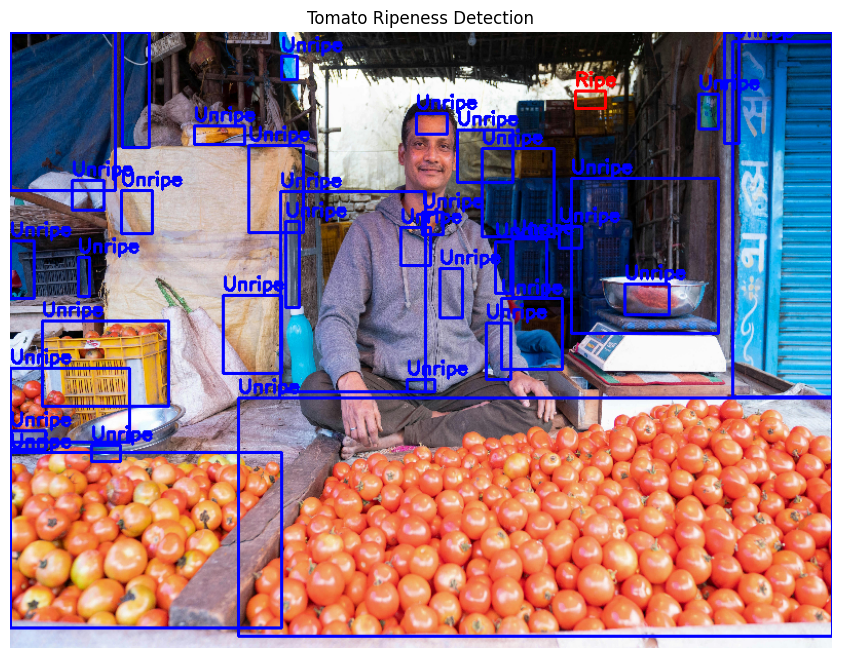

In [11]:
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('/content/51.jpg')
image = cv2.resize(image, (800, 600))
output_img = image.copy()
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Load model & scaler
model = joblib.load('tomato_ripeness_model.pkl')
scaler = joblib.load('scaler.pkl')

# Masks
ripe_mask1 = cv2.inRange(hsv, (0, 120, 70), (10, 255, 255))
ripe_mask2 = cv2.inRange(hsv, (170, 120, 70), (180, 255, 255))
ripe_mask = ripe_mask1 | ripe_mask2
unripe_mask = cv2.inRange(hsv, (11, 50, 50), (169, 255, 255))

# Merge masks
total_mask = ripe_mask | unripe_mask
kernel = np.ones((5, 5), np.uint8)
clean_mask = cv2.morphologyEx(total_mask, cv2.MORPH_OPEN, kernel)

# Contours
contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Detect & draw
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 200:
        x, y, w, h = cv2.boundingRect(cnt)
        roi = image[y:y+h, x:x+w]
        mean_color = cv2.mean(cv2.cvtColor(roi, cv2.COLOR_BGR2HSV))[:3]
        feature_scaled = scaler.transform([mean_color])
        prediction = model.predict(feature_scaled)[0]

        color = (255, 0, 0) if prediction == 0 else (0, 0, 255)  # Blue for unripe, Red for ripe
        label = "Unripe" if prediction == 0 else "Ripe"
        cv2.rectangle(output_img, (x, y), (x+w, y+h), color, 2)
        cv2.putText(output_img, label, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Convert BGR to RGB for display
output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

# Show output
plt.figure(figsize=(12, 8))
plt.imshow(output_rgb)
plt.axis('off')
plt.title("Tomato Ripeness Detection")
plt.show()


Error processing tomato: X has 16 features, but StandardScaler is expecting 3 features as input.
Error processing tomato: X has 16 features, but StandardScaler is expecting 3 features as input.
Error processing tomato: X has 16 features, but StandardScaler is expecting 3 features as input.
Error processing tomato: X has 16 features, but StandardScaler is expecting 3 features as input.
Error processing tomato: X has 16 features, but StandardScaler is expecting 3 features as input.
Error processing tomato: X has 16 features, but StandardScaler is expecting 3 features as input.
Error processing tomato: X has 16 features, but StandardScaler is expecting 3 features as input.


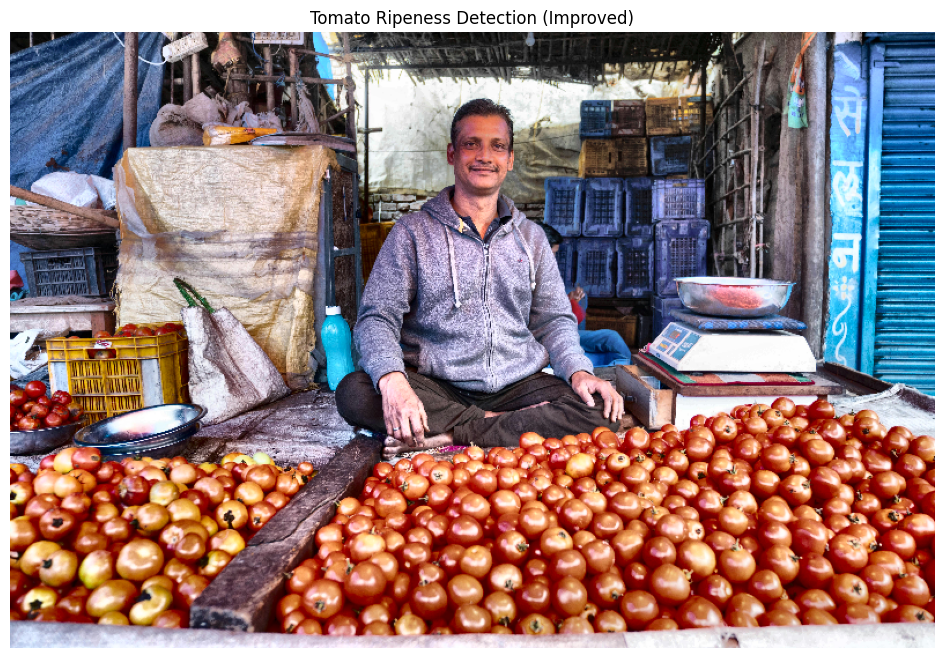

In [12]:
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern

def preprocess_image(image):
    """Enhance image quality and prepare for processing"""
    # Resize while maintaining aspect ratio
    h, w = image.shape[:2]
    new_w = 800
    new_h = int(h * (new_w / w))
    image = cv2.resize(image, (new_w, new_h))

    # Apply CLAHE for contrast enhancement
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    return enhanced

def extract_features(roi):
    """Extract comprehensive features from tomato region"""
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(roi, cv2.COLOR_BGR2LAB)

    # Color features
    mean_hsv = cv2.mean(hsv)[:3]
    std_hsv = cv2.meanStdDev(hsv)[1].flatten()

    # Texture features using LBP
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, 8, 1, method='uniform')
    hist, _ = np.histogram(lbp, bins=np.arange(0, 10), range=(0, 9))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)  # Normalize

    # Shape features
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges) / (roi.shape[0] * roi.shape[1])

    features = np.concatenate([
        mean_hsv,
        std_hsv,
        hist,
        [edge_density]
    ])

    return features

def main():
    # Load image
    image = cv2.imread('/content/51.jpg')
    if image is None:
        print("Error: Image not found")
        return

    # Preprocess image
    image = preprocess_image(image)
    output_img = image.copy()

    # Load model and scaler
    try:
        model = joblib.load('tomato_ripeness_model.pkl')
        scaler = joblib.load('scaler.pkl')
    except FileNotFoundError:
        print("Error: Model files not found")
        return

    # Color segmentation with adaptive thresholds
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Red (ripe) detection - more precise ranges
    ripe_lower1 = np.array([0, 100, 50])
    ripe_upper1 = np.array([10, 255, 255])
    ripe_lower2 = np.array([170, 100, 50])
    ripe_upper2 = np.array([180, 255, 255])

    # Green/yellow (unripe) detection
    unripe_lower = np.array([20, 40, 40])
    unripe_upper = np.array([90, 255, 255])

    ripe_mask1 = cv2.inRange(hsv, ripe_lower1, ripe_upper1)
    ripe_mask2 = cv2.inRange(hsv, ripe_lower2, ripe_upper2)
    ripe_mask = cv2.bitwise_or(ripe_mask1, ripe_mask2)
    unripe_mask = cv2.inRange(hsv, unripe_lower, unripe_upper)

    # Combine masks and clean up
    total_mask = cv2.bitwise_or(ripe_mask, unripe_mask)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    clean_mask = cv2.morphologyEx(total_mask, cv2.MORPH_OPEN, kernel, iterations=2)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Find contours
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Process each detected tomato
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 500:  # Skip small areas
            continue

        # Get bounding box and ROI
        x, y, w, h = cv2.boundingRect(cnt)
        roi = image[y:y+h, x:x+w]

        # Extract comprehensive features
        features = extract_features(roi)

        try:
            # Scale features and predict
            features_scaled = scaler.transform([features])
            prediction = model.predict(features_scaled)[0]
            proba = model.predict_proba(features_scaled)[0]

            # Determine ripeness level and confidence
            if prediction == 1:  # Ripe
                confidence = proba[1]
                color = (0, 0, 255)  # Red
                label = f"Ripe ({confidence:.1%})"
            else:  # Unripe
                confidence = proba[0]
                color = (0, 255, 0)  # Green
                label = f"Unripe ({confidence:.1%})"

            # Draw results
            cv2.rectangle(output_img, (x, y), (x+w, y+h), color, 2)
            cv2.putText(output_img, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        except Exception as e:
            print(f"Error processing tomato: {e}")
            continue

    # Display results
    output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(output_rgb)
    plt.axis('off')
    plt.title("Tomato Ripeness Detection (Improved)")
    plt.show()

if __name__ == "__main__":
    main()